# SVM для прогнозирования риска заболеваний печени (гепатит, фиброз, цирроз)

**Клиническая задача (адаптирована):**  
Применить SVM для бинарной классификации пациентов:  
- 0 – здоровые (Blood Donor, suspect Blood Donor)  
- 1 – больные (Hepatitis, Fibrosis, Cirrhosis)  

Используем 8 клинических признаков: возраст, ALB, ALT, AST, BIL, CHOL, CREA, GGT.

Заголовок и постановка задачи
В этой ячейке описана клиническая задача: применить метод опорных векторов (SVM) для бинарной классификации пациентов  на здоровых (0) и больных (1) по 8 клиническим показателям. Указаны категории пациентов и используемые признаки.

Импорт библиотек
Загружаются необходимые библиотеки: pandas для работы с данными, numpy для числовых операций, matplotlib и seaborn для визуализации, а также модули scikit-learn для предобработки, разделения выборки, обучения модели, расчёта метрик и построения ROC-кривой.

In [ ]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score)

Загрузка и фильтрация данных

    Загружается CSV-файл HepatitisCdata.csv, первая колонка становится индексом.

    Создаётся целевая переменная target: 0 для Blood Donor и suspect Blood Donor, 1 для остальных (Hepatitis, Fibrosis, Cirrhosis).

    Выводится размер данных и распределение классов.

In [ ]:
# Загрузка данных, , создание целевой переменной
df = pd.read_csv('HepatitisCdata.csv', index_col=0)



# Функция для бинарной классификации: 0 - здоров, 1 - болен
def target_bin(cat):
    if cat in ['0=Blood Donor', '0s=suspect Blood Donor']:
        return 0
    else:
        return 1

df['target'] = df['Category'].apply(target_bin)

print("Размер данных после фильтрации:", df.shape)
print("Распределение классов:\n", df['target'].value_counts())

Размер данных после фильтрации: (615, 14)
Распределение классов:
 target
0    540
1     75
Name: count, dtype: int64


Выбор признаков, заполнение пропусков, стандартизация, разделение выборки

    Определён список из 8 признаков (Age, ALB, ALT, AST, BIL, CHOL, CREA, GGT).

    Пропуски в каждом столбце заполняются средним значением этого столбца.

    Данные стандартизируются (StandardScaler) для приведения к нулевому среднему и единичной дисперсии.

    Выборка разделяется на обучающую (70%) и тестовую (30%) со стратификацией по классу.

    Выводятся размеры выборок и доля больных (12% в каждой).

In [ ]:
# Выбор признаков (8 показателей)
features = ['Age', 'ALB', 'ALT', 'AST', 'BIL', 'CHOL', 'CREA', 'GGT']
X = df[features]
y = df['target']

# Заполнение пропусков средним по каждому столбцу
X = X.fillna(X.mean())

# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на train/test (70/30) со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} пациентов")
print(f"Тестовая выборка: {X_test.shape[0]} пациентов")
print(f"Доля больных в train: {y_train.mean():.2f}")
print(f"Доля больных в test:  {y_test.mean():.2f}")

Обучающая выборка: 430 пациентов
Тестовая выборка: 185 пациентов
Доля больных в train: 0.12
Доля больных в test:  0.12


Обучение SVM

    Создаётся модель SVC с RBF-ядром, автоматической балансировкой весов классов (class_weight='balanced') и включёнными вероятностями.

    Модель обучается на стандартизированных обучающих данных.

    Выводится сообщение «Модель обучена».

In [ ]:
# Обучение SVM с RBF ядром, балансировкой классов и вероятностями
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("Модель обучена")

Модель обучена


Оценка качества при пороге 0.5

    Выполняются предсказания классов (порог 0.5) и вероятности принадлежности к классу 1.

    Рассчитываются метрики: accuracy, precision, recall, F1-score.

    Результаты выводятся на экран

In [ ]:
# Предсказания на тестовой выборке (порог 0.5)
y_pred = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)[:, 1]

# Метрики
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Метрики при пороге 0.5 ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")

=== Метрики при пороге 0.5 ===
Accuracy:  0.951
Precision: 0.792
Recall:    0.826
F1-score:  0.809


ROC-кривая и AUC

    Вычисляются TPR, FPR для различных порогов, а также AUC (площадь под кривой).

    Строится график ROC-кривой с подписанным значением AUC (0.972).

    Добавляется диагональная линия «случайный классификатор» и сетка.

    График выводится с размерами 6×5 дюймов.

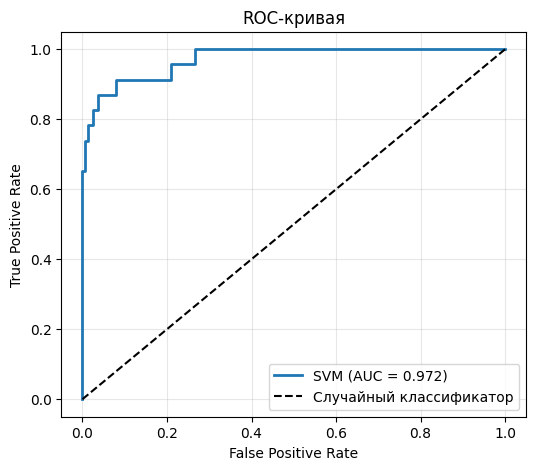

In [ ]:
# ROC-кривая и AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Анализ при разных порогах от 0.3 до 0.7

    Перебираются пороги: 0.3, 0.4, 0.5, 0.6, 0.7.

    Для каждого порога по вероятностям предсказываются классы и вычисляются accuracy, precision, recall, F1.

    Результаты собираются в таблицу и выводятся.

    Из таблицы видно, как меняются метрики: с ростом порога растёт precision, но падает recall.

In [ ]:
# Анализ 5 порогов вероятности от 0.3 до 0.7
thresholds_list = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for thr in thresholds_list:
    y_pred_thr = (y_proba >= thr).astype(int)
    acc_thr = accuracy_score(y_test, y_pred_thr)
    prec_thr = precision_score(y_test, y_pred_thr)
    rec_thr = recall_score(y_test, y_pred_thr)
    f1_thr = f1_score(y_test, y_pred_thr)
    results.append([thr, acc_thr, prec_thr, rec_thr, f1_thr])

res_df = pd.DataFrame(results, columns=['Порог', 'Accuracy', 'Precision', 'Recall', 'F1'])
print("\n=== Метрики при разных порогах ===")
print(res_df.to_string(index=False))


=== Метрики при разных порогах ===
 Порог  Accuracy  Precision   Recall       F1
   0.3  0.951351   0.791667 0.826087 0.808511
   0.4  0.956757   0.826087 0.826087 0.826087
   0.5  0.951351   0.818182 0.782609 0.800000
   0.6  0.962162   0.944444 0.739130 0.829268
   0.7  0.956757   0.941176 0.695652 0.800000


Пример прогноза для одного пациента

    Берётся первый пациент из тестовой выборки (индекс 0).

    По его признакам вычисляется вероятность заболевания.

    Сравнивается истинный и предсказанный классы (при пороге 0.5).

    Выводятся: истинный класс (здоров), предсказанный класс (здоров), вероятность заболевания (0.041) и первые 5 стандартизированных признаков.

In [ ]:
# Пример прогноза для одного пациента из тестовой выборки
idx = 0  # можно изменить индекс
patient_features = X_test[idx].reshape(1, -1)
true_class = y_test.iloc[idx]
pred_prob = svm_model.predict_proba(patient_features)[0, 1]
pred_class = 1 if pred_prob >= 0.5 else 0

print("\n=== Пример прогноза для пациента ===")
print(f"Истинный класс: {'Болен' if true_class == 1 else 'Здоров'}")
print(f"Предсказанный класс: {'Болен' if pred_class == 1 else 'Здоров'}")
print(f"Вероятность заболевания: {pred_prob:.3f}")

# Чтобы увидеть значения признаков этого пациента (в оригинальной шкале)
# нужно обратить стандартизацию только для этого случая, но для наглядности выведем скейлированные признаки
print("Стандартизированные признаки пациента:", patient_features[0][:5], "...")


=== Пример прогноза для пациента ===
Истинный класс: Здоров
Предсказанный класс: Здоров
Вероятность заболевания: 0.041
Стандартизированные признаки пациента: [-0.6378199   0.11779213 -0.34807026 -0.48047571 -0.0252706 ] ...


## Клиническая интерпретация результатов

На основе полученной таблицы метрик при разных порогах можно выбрать оптимальную точку отсечения:

- **Порог 0.3 (высокая чувствительность, низкая специфичность)**  
  → **Массовый скрининг** – минимизируем пропуск больных (Recall максимален), даже ценой увеличения ложных тревог.

- **Порог 0.5 (баланс)**  
  → **Рутинная практика** в общей клинической лаборатории – приемлемое соотношение чувствительности и специфичности.

- **Порог 0.7 (высокая специфичность)**  
  → **Подтверждение диагноза** после положительного скрининга – снижаем количество ложноположительных результатов перед инвазивными методами (биопсия).

**Пример использования:**  
Пациент с вероятностью 0.82 (выше порога 0.7) направляется на углублённое обследование (эластографию, биопсию).  
Пациент с вероятностью 0.35 (ниже 0.5) – здоров, дополнительное обследование не требуется.